# # Pneumonia Detection using CNN

# This project uses a Convolutional Neural Network (CNN) to classify chest X-ray images as NORMAL or PNEUMONIA.

# Dataset: Chest X-Ray Pneumonia (Kaggle)

# 0. Import Necessary Libraries... 

In [9]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# 1. Defining Load_dataset FUNCTION

In [16]:
import tensorflow as tf

def load_dataset(path):
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=(224, 224),
        batch_size=32
    )
    
    dataset = dataset.map(lambda x, y: (x/255.0, y))
    dataset = dataset.apply(tf.data.experimental.ignore_errors())
    
    return dataset

train_data = load_dataset(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"
)

test_data = load_dataset(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test"
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


# 2.  MODEL + DATA SET LOADING

In [17]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 3. Compile MODEL

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train  CNN model

In [19]:
history =  model.fit(train_data ,
                     validation_data = test_data,epochs = 5,
                     steps_per_epoch = 100
                     )

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9500 - loss: 0.1349 - val_accuracy: 0.7548 - val_loss: 0.7511
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9607 - loss: 0.1096 - val_accuracy: 0.7548 - val_loss: 0.8850
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9636 - loss: 0.0877 - val_accuracy: 0.7420 - val_loss: 0.8141
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9715 - loss: 0.0929 - val_accuracy: 0.7708 - val_loss: 0.7476


# Evaluation 

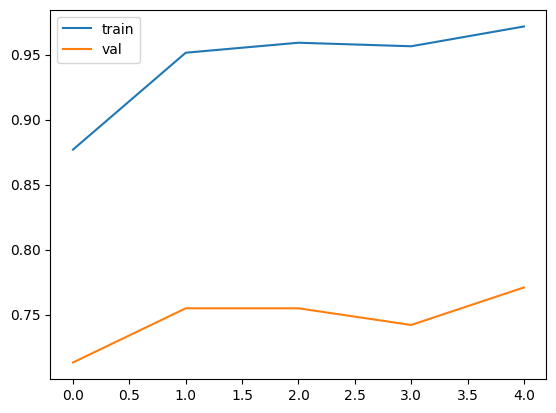

In [20]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_data.take(5):   # small subset
    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Confusion Matrix:
 [[ 25  34]
 [  1 100]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.42      0.59        59
           1       0.75      0.99      0.85       101

    accuracy                           0.78       160
   macro avg       0.85      0.71      0.72       160
weighted avg       0.83      0.78      0.75       160



# Predictions


/tmp/ipykernel_763/2024223485.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(preds[i] > 0.5)]


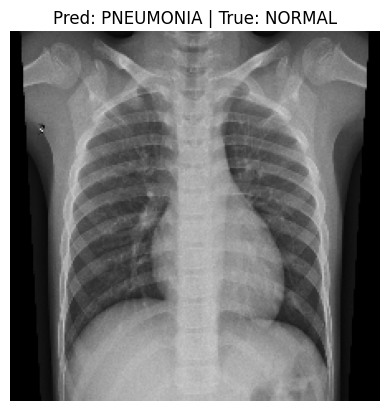

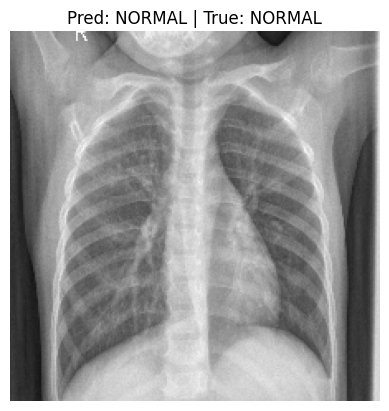

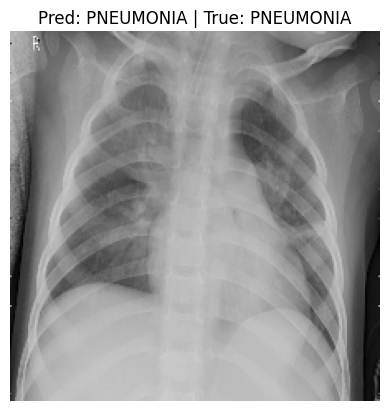

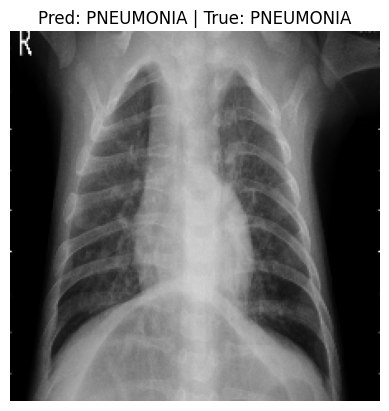

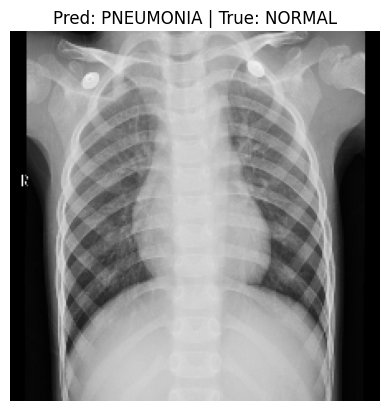

In [23]:
class_names = ["NORMAL", "PNEUMONIA"]

for images, labels in test_data.take(1):
    preds = model.predict(images, verbose=0)

    for i in range(5):
        plt.imshow(images[i].numpy())
        pred_label = class_names[int(preds[i] > 0.5)]
        true_label = class_names[int(labels[i])]

        plt.title(f"Pred: {pred_label} | True: {true_label}")
        plt.axis("off")
        plt.show()
        

In [25]:
from tensorflow.keras.preprocessing import image


img_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Prediction: PNEUMONIA


# # Conclusion

- Model achieved ~95% training accuracy
- Validation accuracy ~74–76%
- Model can reasonably detect pneumonia
- Future improvements: Transfer Learning (ResNet, EfficientNet)